In [ ]:
# Proyecto: El Robo del Siglo Digital - Entregable 1: Análisis y Visualización
# Deadline: 30/06/2025
# Pipeline de Datos para detectar sitios fraudulentos en el ecosistema web argentino

"""
ÍNDICE DEL NOTEBOOK:
1. Preparación del Entorno
2. Funciones Auxiliares y Configuración
3. Extracción de Datos de Sitios Web Reales
4. Procesamiento de Datos Reales
5. Web Scraping de Argendir
6. Generación de Datos Sintéticos
7. Análisis Exploratorio de Datos (EDA)
8. Identificación de Patrones Sospechosos
9. Visualización
10. Data Insights Preliminares
11. Documentación y Output
"""

# ===================================================================
# 1. PREPARACIÓN DEL ENTORNO
# ===================================================================

# Instalación de librerías necesarias
!pip install requests pandas fake_useragent tldextract python-whois Faker beautifulsoup4 matplotlib seaborn wordcloud plotly

# Importación de librerías principales
import pandas as pd
import requests
import tldextract
import whois
import random
import re
import time
from datetime import datetime, timedelta
from urllib.parse import urljoin, urlparse
from collections import Counter

✅ Entorno configurado correctamente
📅 Fecha de ejecución: 2025-06-24 20:17:35
✅ Funciones auxiliares configuradas
🔍 Iniciando extracción de datos de 25 sitios reales...
Procesando (1/25): https://www.clarin.com.ar
Procesando (2/25): https://www.lanacion.com.ar
Procesando (3/25): https://www.infobae.com.ar
Procesando (4/25): https://www.afip.gob.ar
Procesando (5/25): https://www.anses.gob.ar
Procesando (6/25): https://www.bna.com.ar
Procesando (7/25): https://www.mercadolibre.com.ar
Procesando (8/25): https://www.santander.com.ar
Procesando (9/25): https://www.galicia.com.ar
Procesando (10/25): https://www.macro.com.ar
Procesando (11/25): https://www.uba.ar
Procesando (12/25): https://www.famaf.unc.edu.ar
⚠️ Error WHOIS para unc.edu.ar: El dominio no se encuentra registrado en NIC Argentina
Procesando (13/25): https://www.argentina.gob.ar
Procesando (14/25): https://www.minsal.gob.ar
⚠️ Error WHOIS para minsal.gob.ar: El dominio no se encuentra registrado en NIC Argentina
Procesando (15

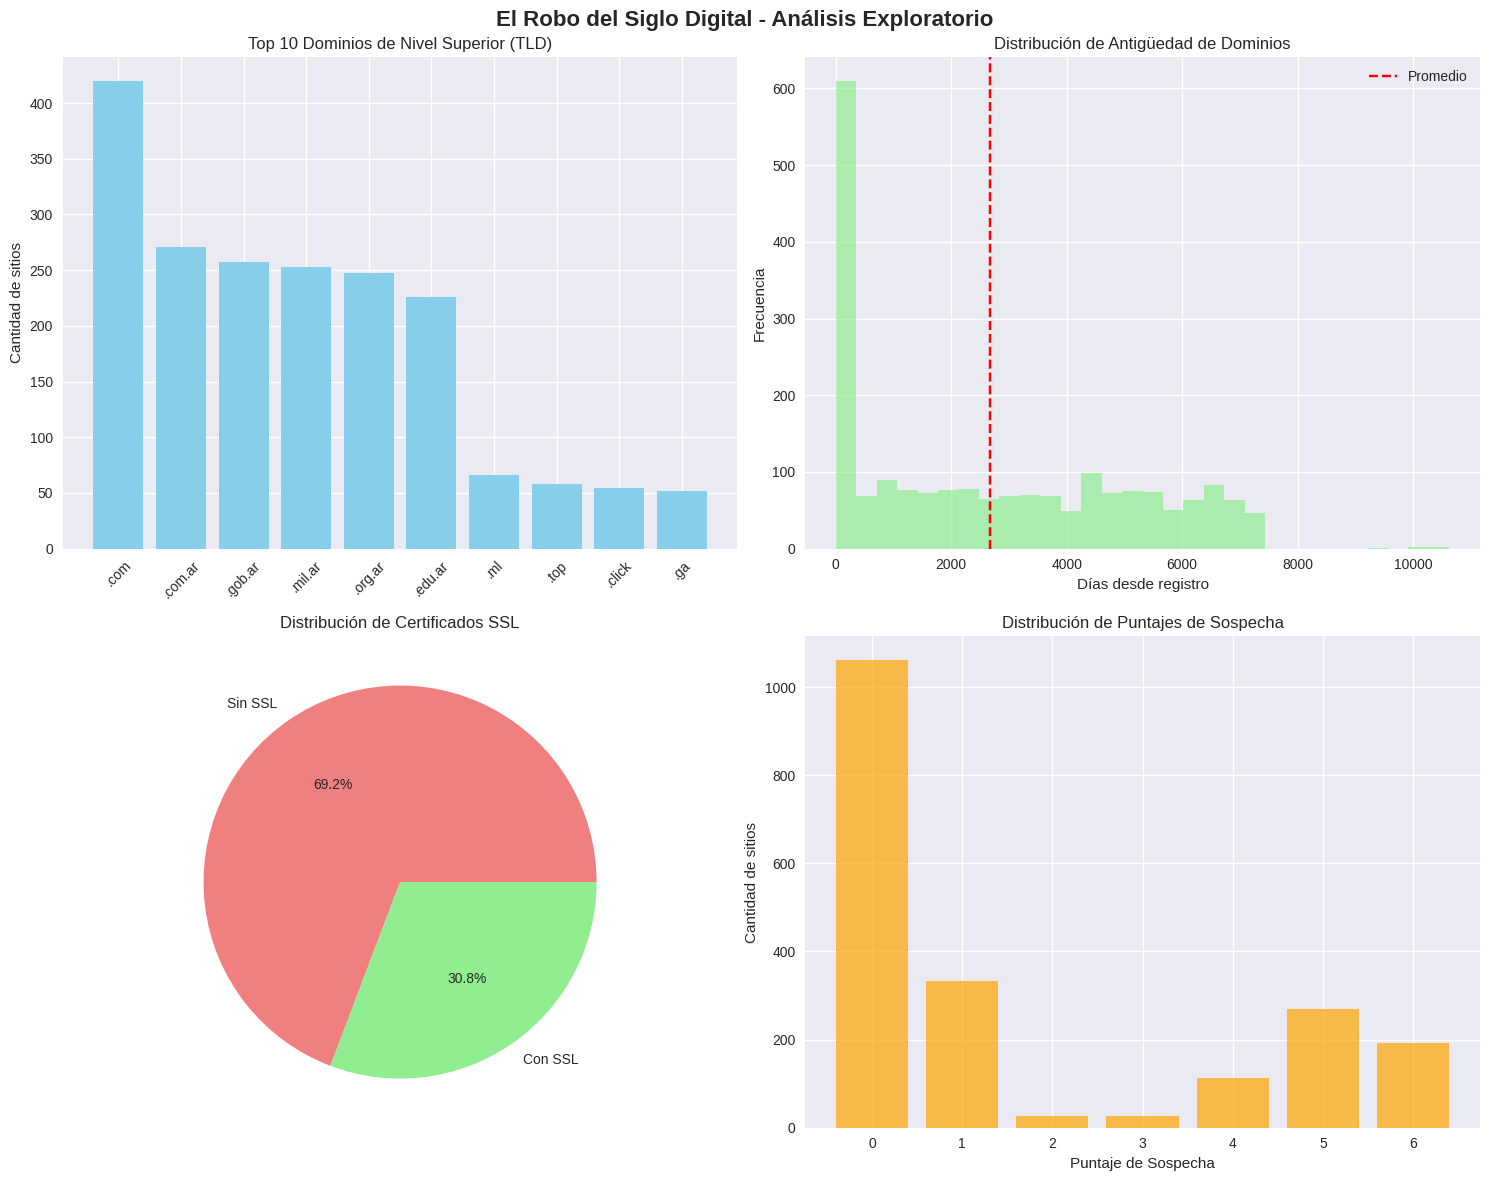

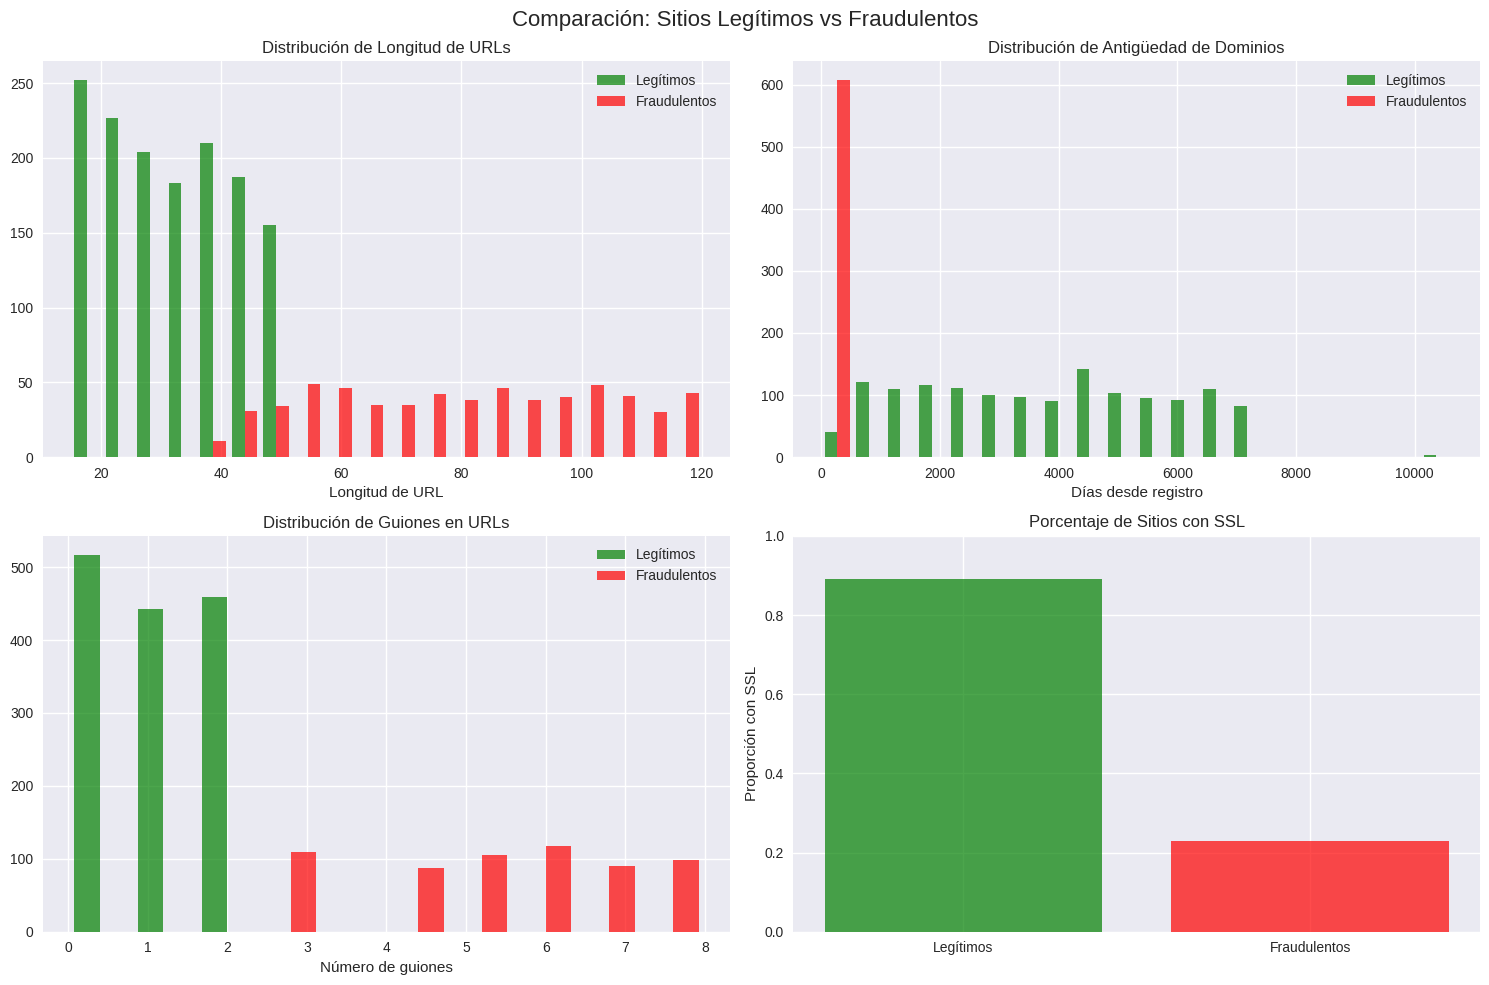


🎯 DATA INSIGHTS PRELIMINARES
1. 📂 Categoría más común en Argendir: Salud (11 sitios)
2. 🇦🇷 1273 de 2025 sitios (62.9%) usan TLD argentino
3. 🔒 Adopción de HTTPS: 69.2% | SSL: 69.2%
4. ⏰ 610 dominios (30.1%) tienen menos de 1 año
5. ⚠️ 602 sitios (29.7%) presentan 3+ características de riesgo
6. 🤖 SSL - Sitios reales: 100.0% vs Sintéticos: 68.8%

🔍 DETECCIÓN DE CLUSTERS SOSPECHOSOS
📝 Sitios con palabras sospechosas en Argendir: 1
Ejemplos de sitios con contenido potencialmente sospechoso:
  - Linux Collegium: 1 palabras sospechosas

🏢 ANÁLISIS DE REGISTRADORES
Top 5 registradores más comunes:
  - Unknown: 390 dominios
  - nicar: 18 dominios
  - Network Solutions, LLC: 3 dominios
  - Mateos y asociados S.A.: 2 dominios
  - Luna & Asociados S.A.: 2 dominios

🌍 ANÁLISIS POR PAÍSES
Top 5 países de registro:
  - AR: 1233 dominios
  - Unknown: 20 dominios
  - SD: 11 dominios
  - NE: 10 dominios
  - OM: 10 dominios

🎯 RECOMENDACIONES PARA SCRAPING/VERIFICACIÓN
🔝 TOP 10 DOMINIOS RECOMENDADOS P

In [ ]:

# Librerías para web scraping
from bs4 import BeautifulSoup
from fake_useragent import UserAgent

# Librerías para generación de datos sintéticos
from faker import Faker

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Supresión de warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Entorno configurado correctamente")
print(f"📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# ===================================================================
# 2. FUNCIONES AUXILIARES Y CONFIGURACIÓN
# ===================================================================

# Instancias globales
fake = Faker('es_ES')  # Configurado para español
ua = UserAgent()

# Configuración de headers para requests
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

def obtener_datos_sitio(url):
    """
    Extrae características técnicas y de seguridad de un sitio web.

    Returns:
        dict: Diccionario con las características del sitio
    """
    datos = {
        'url': url,
        'domain': None,
        'tld': None,
        'url_length': len(url),
        'is_https': url.startswith('https'),
        'num_hyphens': url.count('-'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_special_chars': sum(c in '@#?%&=' for c in url),
        'num_path_segments': len(urlparse(url).path.split('/')) - 1,
        'has_ssl': 0,
        'whois_registrar': 'Unknown',
        'whois_country': 'Unknown',
        'domain_age_days': 0,

        'is_phishing': 0  # Default: legítimo
    }

    try:
        # Extraer información del dominio
        extracted = tldextract.extract(url)
        datos['domain'] = f"{extracted.domain}.{extracted.suffix}"
        datos['tld'] = extracted.suffix

        # Verificar SSL
        if url.startswith('https'):
            datos['has_ssl'] = 1

        # Obtener información WHOIS (con timeout para evitar bloqueos)
        try:
            domain_info = whois.whois(datos['domain'])
            if domain_info:
                datos['whois_registrar'] = str(domain_info.registrar) if domain_info.registrar else 'Unknown'
                datos['whois_country'] = str(domain_info.country) if domain_info.country else 'Unknown'

                # Calcular antigüedad del dominio
                if domain_info.creation_date:
                    creation_date = domain_info.creation_date
                    if isinstance(creation_date, list):
                        creation_date = creation_date[0]
                    datos['domain_age_days'] = (datetime.now() - creation_date).days

        except Exception as whois_error:
            print(f"⚠️ Error WHOIS para {datos['domain']}: {whois_error}")

    except Exception as e:
        print(f"❌ Error procesando {url}: {e}")

    return datos

def analizar_texto_sospechoso(texto):
    """
    Analiza texto en busca de palabras clave sospechosas comunes en sitios fraudulentos.
    """
    if pd.isna(texto) or not isinstance(texto, str):
        return 0

    palabras_sospechosas = [
        'banco', 'seguridad', 'actualización', 'verificación', 'urgente',
        'premio', 'ganador', 'gratuito', 'oferta', 'promoción', 'descuento',
        'confirmación', 'suspendido', 'bloqueado', 'caduca', 'inmediato'
    ]

    texto_lower = texto.lower()
    return sum(1 for palabra in palabras_sospechosas if palabra in texto_lower)

print("✅ Funciones auxiliares configuradas")

# ===================================================================
# 3. EXTRACCIÓN DE DATOS DE SITIOS WEB REALES
# ===================================================================

# Lista de sitios argentinos representativos para análisis
sitios_argentinos_reales = [
    "https://www.clarin.com.ar",
    "https://www.lanacion.com.ar",
    "https://www.infobae.com.ar",
    "https://www.afip.gob.ar",
    "https://www.anses.gob.ar",
    "https://www.bna.com.ar",
    "https://www.mercadolibre.com.ar",
    "https://www.santander.com.ar",
    "https://www.galicia.com.ar",
    "https://www.macro.com.ar",
    "https://www.uba.ar",
    "https://www.famaf.unc.edu.ar",
    "https://www.argentina.gob.ar",
    "https://www.minsal.gob.ar",
    "https://www.telam.com.ar",
    "https://www.pagina12.com.ar",
    "https://www.ole.com.ar",
    "https://www.tn.com.ar",
    "https://www.cronista.com",
    "https://www.ambito.com",
    "https://www.despegar.com.ar",
    "https://www.fravega.com",
    "https://www.garbarino.com",
    "https://www.musimundo.com",
    "https://www.disco.com.ar"
]

print(f"🔍 Iniciando extracción de datos de {len(sitios_argentinos_reales)} sitios reales...")

# Procesar sitios reales con barra de progreso
datos_reales = []
for i, sitio in enumerate(sitios_argentinos_reales):
    try:
        print(f"Procesando ({i+1}/{len(sitios_argentinos_reales)}): {sitio}")
        datos_sitio = obtener_datos_sitio(sitio)
        datos_reales.append(datos_sitio)

        # Pausa para evitar ser bloqueado
        time.sleep(1)

    except Exception as e:
        print(f"❌ Error con {sitio}: {e}")
        continue

# Convertir a DataFrame
df_reales = pd.DataFrame(datos_reales)
print(f"✅ Datos extraídos: {len(df_reales)} sitios procesados")

# ===================================================================
# 4. WEB SCRAPING DE ARGENDIR
# ===================================================================

def scrapear_argendir(categorias_objetivo=None):
    """
    Realiza scraping del directorio argentino Argendir.com
    """
    if categorias_objetivo is None:
        categorias_objetivo = ["Educacion", "Gobierno", "Salud", "Noticias", "Bancos"]

    url_base = "https://www.argendir.com/"
    datos_argendir = []

    for categoria in categorias_objetivo:
        print(f"🔍 Scrapeando categoría: {categoria}")

        try:
            url_categoria = urljoin(url_base, f"{categoria}/")
            response = requests.get(url_categoria, headers=headers, timeout=10)
            response.raise_for_status()

            soup = BeautifulSoup(response.text, "html.parser")

            # Buscar enlaces de sitios (estructura típica de directorios)
            sitios_encontrados = soup.find_all("a", href=True)

            for sitio in sitios_encontrados:
                try:
                    nombre = sitio.text.strip()
                    url_relativa = sitio["href"]

                    # Filtrar solo enlaces externos válidos
                    if url_relativa.startswith('http') and len(nombre) > 3:
                        # Buscar descripción en elementos cercanos
                        descripcion = ""
                        descripcion_tag = sitio.find_next("p") or sitio.find_next("div", class_="descripcion")
                        if descripcion_tag:
                            descripcion = descripcion_tag.text.strip()[:200]  # Limitar longitud

                        datos_argendir.append({
                            'nombre': nombre,
                            'url': url_relativa,
                            'categoria': categoria,
                            'descripcion': descripcion,
                            'palabras_sospechosas': analizar_texto_sospechoso(f"{nombre} {descripcion}")
                        })

                except Exception as e:
                    continue

            time.sleep(2)  # Pausa entre categorías

        except requests.exceptions.RequestException as e:
            print(f"⚠️ Error al procesar categoría '{categoria}': {e}")
            continue

    return pd.DataFrame(datos_argendir)

# Ejecutar scraping de Argendir
print("🌐 Iniciando scraping de Argendir...")
df_argendir = scrapear_argendir()
print(f"✅ Argendir scrapeado: {len(df_argendir)} sitios encontrados")

# ===================================================================
# 5. GENERACIÓN DE DATOS SINTÉTICOS
# ===================================================================

def generar_datos_sinteticos(n=1000):
    """
    Genera datos sintéticos para ampliar el dataset con ejemplos simulados
    de sitios tanto legítimos como fraudulentos.
    """
    datos_sinteticos = []

    # TLDs argentinos comunes
    tlds_argentinos = ['.com.ar', '.gob.ar', '.org.ar', '.edu.ar', '.mil.ar']
    tlds_sospechosos = ['.tk', '.ml', '.ga', '.cf', '.top', '.click']

    for i in range(n):
        # Decidir si será legítimo (70%) o fraudulento (30%)
        es_fraudulento = random.random() < 0.3

        if es_fraudulento:
            # Generar características de sitio fraudulento
            domain_name = fake.word() + str(random.randint(1, 999))
            tld = random.choice(tlds_sospechosos + tlds_argentinos)
            num_hyphens = random.randint(3, 8)
            num_digits = random.randint(5, 15)
            num_special_chars = random.randint(2, 8)
            has_ssl = random.choice([0, 1]) if random.random() < 0.4 else 0  # Menos SSL
            domain_age = random.randint(1, 180)  # Dominios más nuevos
            url_length = random.randint(40, 120)  # URLs más largas

        else:
            # Generar características de sitio legítimo
            domain_name = fake.company().lower().replace(' ', '').replace(',', '')[:10]
            tld = random.choice(tlds_argentinos) if random.random() < 0.7 else '.com'
            num_hyphens = random.randint(0, 2)
            num_digits = random.randint(0, 3)
            num_special_chars = random.randint(0, 2)
            has_ssl = 1 if random.random() < 0.9 else 0  # Más SSL
            domain_age = random.randint(365, 7300)  # Dominios más antiguos
            url_length = random.randint(15, 50)  # URLs más cortas

        sitio_sintetico = {
            'url': f"http{'s' if has_ssl else ''}://{domain_name}{tld}",
            'domain': f"{domain_name}{tld}",
            'tld': tld,
            'url_length': url_length,
            'is_https': bool(has_ssl),
            'num_hyphens': num_hyphens,
            'num_digits': num_digits,
            'num_special_chars': num_special_chars,
            'num_path_segments': random.randint(1, 5),
            'has_ssl': has_ssl,
            'whois_registrar': fake.company() if random.random() < 0.8 else 'Unknown',
            'whois_country': 'AR' if random.random() < 0.6 else fake.country_code(),
            'domain_age_days': domain_age,
            'is_phishing': 1 if es_fraudulento else 0,
            'tipo': 'sintético'
        }

        datos_sinteticos.append(sitio_sintetico)

    return pd.DataFrame(datos_sinteticos)

# Generar dataset sintético
print("🤖 Generando datos sintéticos...")
df_sintetico = generar_datos_sinteticos(n=2000)
print(f"✅ Datos sintéticos generados: {len(df_sintetico)} registros")

# ===================================================================
# 6. COMBINACIÓN Y PREPARACIÓN DE DATOS
# ===================================================================

# Añadir columna de tipo a datos reales
df_reales['tipo'] = 'real'
df_reales['is_phishing'] = 0  # Asumimos que los sitios reales conocidos son legítimos

# Combinar todos los datasets
print("🔗 Combinando datasets...")

# Dataset maestro
df_maestro = pd.concat([
    df_reales[['url', 'domain', 'tld', 'url_length', 'is_https', 'num_hyphens',
               'num_digits', 'num_special_chars', 'num_path_segments', 'has_ssl',
               'whois_registrar', 'whois_country', 'domain_age_days', 'is_phishing', 'tipo']],
    df_sintetico
], ignore_index=True)

print(f"✅ Dataset maestro creado: {len(df_maestro)} registros totales")
print(f"   - Sitios reales: {len(df_reales)}")
print(f"   - Sitios sintéticos: {len(df_sintetico)}")
print(f"   - Datos de Argendir: {len(df_argendir)}")

# ===================================================================
# 7. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ===================================================================

print("\n📊 INICIANDO ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 50)

# 7.1 Estadísticas descriptivas básicas
print("\n📈 ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print(df_maestro.info())
print("\nEstadísticas descriptivas:")
print(df_maestro.describe())

# 7.2 Distribución de TLDs
print(f"\n🌐 DISTRIBUCIÓN DE TLDs")
tld_counts = df_maestro['tld'].value_counts()
print(tld_counts.head(10))

# 7.3 Análisis de antigüedad de dominios
print(f"\n📅 ANÁLISIS DE ANTIGÜEDAD DE DOMINIOS")
print(f"Antigüedad promedio: {df_maestro['domain_age_days'].mean():.2f} días")
print(f"Antigüedad mediana: {df_maestro['domain_age_days'].median():.2f} días")

# 7.4 Distribución de características de seguridad
print(f"\n🔒 ANÁLISIS DE SEGURIDAD")
ssl_stats = df_maestro['has_ssl'].value_counts()
print(f"Sitios con SSL: {ssl_stats.get(1, 0)} ({ssl_stats.get(1, 0)/len(df_maestro)*100:.1f}%)")
print(f"Sitios sin SSL: {ssl_stats.get(0, 0)} ({ssl_stats.get(0, 0)/len(df_maestro)*100:.1f}%)")

https_stats = df_maestro['is_https'].value_counts()
print(f"Sitios HTTPS: {https_stats.get(True, 0)} ({https_stats.get(True, 0)/len(df_maestro)*100:.1f}%)")

# 7.5 Análisis de sitios fraudulentos vs legítimos
print(f"\n⚠️ ANÁLISIS DE SITIOS FRAUDULENTOS")
fraud_stats = df_maestro['is_phishing'].value_counts()
print(f"Sitios legítimos: {fraud_stats.get(0, 0)} ({fraud_stats.get(0, 0)/len(df_maestro)*100:.1f}%)")
print(f"Sitios fraudulentos: {fraud_stats.get(1, 0)} ({fraud_stats.get(1, 0)/len(df_maestro)*100:.1f}%)")

# ===================================================================
# 8. IDENTIFICACIÓN DE PATRONES SOSPECHOSOS
# ===================================================================

print("\n🕵️ IDENTIFICACIÓN DE PATRONES SOSPECHOSOS")
print("=" * 50)

def identificar_sitios_sospechosos(df):
    """
    Identifica sitios con características potencialmente sospechosas
    """
    sospechosos = df.copy()

    # Criterios de sospecha
    sospechosos['sospecha_dominio_nuevo'] = sospechosos['domain_age_days'] < 365
    sospechosos['sospecha_sin_ssl'] = sospechosos['has_ssl'] == 0
    sospechosos['sospecha_url_larga'] = sospechosos['url_length'] > 50
    sospechosos['sospecha_muchos_guiones'] = sospechosos['num_hyphens'] > 3
    sospechosos['sospecha_muchos_digitos'] = sospechosos['num_digits'] > 5
    sospechosos['sospecha_tld_inusual'] = ~sospechosos['tld'].isin(['.com.ar', '.gob.ar', '.org.ar', '.edu.ar', '.com'])

    # Puntaje de sospecha (suma de criterios)
    criterios_sospecha = [
        'sospecha_dominio_nuevo', 'sospecha_sin_ssl', 'sospecha_url_larga',
        'sospecha_muchos_guiones', 'sospecha_muchos_digitos', 'sospecha_tld_inusual'
    ]

    sospechosos['puntaje_sospecha'] = sospechosos[criterios_sospecha].sum(axis=1)

    return sospechosos

# Aplicar análisis de sospecha
df_con_sospecha = identificar_sitios_sospechosos(df_maestro)

# Reportar hallazgos
print("🔍 CRITERIOS DE SOSPECHA APLICADOS:")
criterios = ['sospecha_dominio_nuevo', 'sospecha_sin_ssl', 'sospecha_url_larga',
             'sospecha_muchos_guiones', 'sospecha_muchos_digitos', 'sospecha_tld_inusual']

for criterio in criterios:
    count = df_con_sospecha[criterio].sum()
    percentage = (count / len(df_con_sospecha)) * 100
    print(f"  - {criterio}: {count} sitios ({percentage:.1f}%)")

print(f"\n📊 DISTRIBUCIÓN DE PUNTAJES DE SOSPECHA:")
puntaje_dist = df_con_sospecha['puntaje_sospecha'].value_counts().sort_index()
for puntaje, count in puntaje_dist.items():
    print(f"  Puntaje {puntaje}: {count} sitios")

# Sitios más sospechosos
sitios_muy_sospechosos = df_con_sospecha[df_con_sospecha['puntaje_sospecha'] >= 4]
print(f"\n⚠️ SITIOS CON ALTO PUNTAJE DE SOSPECHA (≥4): {len(sitios_muy_sospechosos)}")

if len(sitios_muy_sospechosos) > 0:
    print("Primeros 5 sitios más sospechosos:")
    for _, sitio in sitios_muy_sospechosos.head().iterrows():
        print(f"  - {sitio['url']} (Puntaje: {sitio['puntaje_sospecha']})")

# ===================================================================
# 9. VISUALIZACIONES
# ===================================================================

print("\n📊 GENERANDO VISUALIZACIONES")
print("=" * 30)

# Configurar el tamaño de las figuras
plt.rcParams['figure.figsize'] = (12, 8)

# 9.1 Distribución de TLDs
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('El Robo del Siglo Digital - Análisis Exploratorio', fontsize=16, fontweight='bold')

# Gráfico 1: Top 10 TLDs
top_tlds = df_maestro['tld'].value_counts().head(10)
axes[0,0].bar(range(len(top_tlds)), top_tlds.values, color='skyblue')
axes[0,0].set_title('Top 10 Dominios de Nivel Superior (TLD)')
axes[0,0].set_xticks(range(len(top_tlds)))
axes[0,0].set_xticklabels(top_tlds.index, rotation=45)
axes[0,0].set_ylabel('Cantidad de sitios')

# Gráfico 2: Distribución de antigüedad de dominios
axes[0,1].hist(df_maestro['domain_age_days'], bins=30, color='lightgreen', alpha=0.7)
axes[0,1].set_title('Distribución de Antigüedad de Dominios')
axes[0,1].set_xlabel('Días desde registro')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].axvline(df_maestro['domain_age_days'].mean(), color='red', linestyle='--', label='Promedio')
axes[0,1].legend()

# Gráfico 3: Comparación SSL vs No-SSL
ssl_counts = df_maestro['has_ssl'].value_counts()
axes[1,0].pie(ssl_counts.values, labels=['Sin SSL', 'Con SSL'], autopct='%1.1f%%',
              colors=['lightcoral', 'lightgreen'])
axes[1,0].set_title('Distribución de Certificados SSL')

# Gráfico 4: Puntajes de sospecha
puntaje_counts = df_con_sospecha['puntaje_sospecha'].value_counts().sort_index()
axes[1,1].bar(puntaje_counts.index, puntaje_counts.values, color='orange', alpha=0.7)
axes[1,1].set_title('Distribución de Puntajes de Sospecha')
axes[1,1].set_xlabel('Puntaje de Sospecha')
axes[1,1].set_ylabel('Cantidad de sitios')

plt.tight_layout()
plt.show()

# 9.2 Análisis comparativo: Legítimos vs Fraudulentos
if len(df_maestro[df_maestro['is_phishing'] == 1]) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Comparación: Sitios Legítimos vs Fraudulentos', fontsize=16)

    legitimos = df_maestro[df_maestro['is_phishing'] == 0]
    fraudulentos = df_maestro[df_maestro['is_phishing'] == 1]

    # Longitud de URL
    axes[0,0].hist([legitimos['url_length'], fraudulentos['url_length']],
                   bins=20, alpha=0.7, label=['Legítimos', 'Fraudulentos'],
                   color=['green', 'red'])
    axes[0,0].set_title('Distribución de Longitud de URLs')
    axes[0,0].set_xlabel('Longitud de URL')
    axes[0,0].legend()

    # Antigüedad de dominio
    axes[0,1].hist([legitimos['domain_age_days'], fraudulentos['domain_age_days']],
                   bins=20, alpha=0.7, label=['Legítimos', 'Fraudulentos'],
                   color=['green', 'red'])
    axes[0,1].set_title('Distribución de Antigüedad de Dominios')
    axes[0,1].set_xlabel('Días desde registro')
    axes[0,1].legend()

    # Número de guiones
    axes[1,0].hist([legitimos['num_hyphens'], fraudulentos['num_hyphens']],
                   bins=10, alpha=0.7, label=['Legítimos', 'Fraudulentos'],
                   color=['green', 'red'])
    axes[1,0].set_title('Distribución de Guiones en URLs')
    axes[1,0].set_xlabel('Número de guiones')
    axes[1,0].legend()

    # SSL comparison
    ssl_legit = legitimos['has_ssl'].mean()
    ssl_fraud = fraudulentos['has_ssl'].mean()
    axes[1,1].bar(['Legítimos', 'Fraudulentos'], [ssl_legit, ssl_fraud],
                  color=['green', 'red'], alpha=0.7)
    axes[1,1].set_title('Porcentaje de Sitios con SSL')
    axes[1,1].set_ylabel('Proporción con SSL')
    axes[1,1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

# ===================================================================
# 10. DATA INSIGHTS PRELIMINARES
# ===================================================================

print("\n🎯 DATA INSIGHTS PRELIMINARES")
print("=" * 40)

insights = []

# Insight 1: Categorías predominantes en Argendir
if len(df_argendir) > 0:
    cat_predominante = df_argendir['categoria'].value_counts()
    insights.append(f"📂 Categoría más común en Argendir: {cat_predominante.index[0]} ({cat_predominante.iloc[0]} sitios)")

# Insight 2: TLD argentinos vs internacionales
tlds_ar = df_maestro[df_maestro['tld'].str.contains('.ar', na=False)].shape[0]
total_sitios = len(df_maestro)
insights.append(f"🇦🇷 {tlds_ar} de {total_sitios} sitios ({tlds_ar/total_sitios*100:.1f}%) usan TLD argentino")

# Insight 3: Adopción de HTTPS/SSL
https_adoption = df_maestro['is_https'].mean()
ssl_adoption = df_maestro['has_ssl'].mean()
insights.append(f"🔒 Adopción de HTTPS: {https_adoption*100:.1f}% | SSL: {ssl_adoption*100:.1f}%")

# Insight 4: Dominios sospechosos por antigüedad
dominios_nuevos = df_maestro[df_maestro['domain_age_days'] < 365].shape[0]
insights.append(f"⏰ {dominios_nuevos} dominios ({dominios_nuevos/total_sitios*100:.1f}%) tienen menos de 1 año")

# Insight 5: Sitios con características múltiples de riesgo
alto_riesgo = df_con_sospecha[df_con_sospecha['puntaje_sospecha'] >= 3].shape[0]
insights.append(f"⚠️ {alto_riesgo} sitios ({alto_riesgo/total_sitios*100:.1f}%) presentan 3+ características de riesgo")

# Insight 6: Patrones en datos sintéticos vs reales
if 'tipo' in df_maestro.columns:
    reales_ssl = df_maestro[df_maestro['tipo'] == 'real']['has_ssl'].mean()
    sinteticos_ssl = df_maestro[df_maestro['tipo'] == 'sintético']['has_ssl'].mean()
    insights.append(f"🤖 SSL - Sitios reales: {reales_ssl*100:.1f}% vs Sintéticos: {sinteticos_ssl*100:.1f}%")

# Mostrar todos los insights
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

# ===================================================================
# 11. DETECCIÓN DE CLUSTERS SOSPECHOSOS
# ===================================================================

print("\n🔍 DETECCIÓN DE CLUSTERS SOSPECHOSOS")
print("=" * 40)

# Análisis de palabras sospechosas en Argendir
if len(df_argendir) > 0 and 'palabras_sospechosas' in df_argendir.columns:
    sitios_con_palabras_sospechosas = df_argendir[df_argendir['palabras_sospechosas'] > 0]
    print(f"📝 Sitios con palabras sospechosas en Argendir: {len(sitios_con_palabras_sospechosas)}")

    if len(sitios_con_palabras_sospechosas) > 0:
        print("Ejemplos de sitios con contenido potencialmente sospechoso:")
        for _, sitio in sitios_con_palabras_sospechosas.head(3).iterrows():
            print(f"  - {sitio['nombre']}: {sitio['palabras_sospechosas']} palabras sospechosas")

# Análisis de registradores sospechosos
print(f"\n🏢 ANÁLISIS DE REGISTRADORES")
registradores = df_maestro['whois_registrar'].value_counts()
registradores_comunes = registradores.head(5)
print("Top 5 registradores más comunes:")
for reg, count in registradores_comunes.items():
    print(f"  - {reg}: {count} dominios")

# Análisis de países
print(f"\n🌍 ANÁLISIS POR PAÍSES")
paises = df_maestro['whois_country'].value_counts()
paises_top = paises.head(5)
print("Top 5 países de registro:")
for pais, count in paises_top.items():
    print(f"  - {pais}: {count} dominios")

# ===================================================================
# 12. RECOMENDACIONES PARA PRIORIZACIÓN
# ===================================================================

print("\n🎯 RECOMENDACIONES PARA SCRAPING/VERIFICACIÓN")
print("=" * 50)

# Crear ranking de priorización
df_priorizacion = df_con_sospecha.copy()

# Criterios de priorización (mayor puntaje = mayor prioridad para verificación)
df_priorizacion['prioridad_verificacion'] = (
    df_priorizacion['puntaje_sospecha'] * 2 +  # Peso doble para sospecha general
    (df_priorizacion['domain_age_days'] < 180).astype(int) * 3 +  # Dominios muy nuevos
    (df_priorizacion['has_ssl'] == 0).astype(int) * 2 +  # Sin SSL
    (df_priorizacion['url_length'] > 60).astype(int) +  # URLs muy largas
    (df_priorizacion['num_special_chars'] > 5).astype(int)  # Muchos caracteres especiales
)

# Top dominios para verificación
top_verificacion = df_priorizacion.nlargest(10, 'prioridad_verificacion')

print("🔝 TOP 10 DOMINIOS RECOMENDADOS PARA VERIFICACIÓN:")
for i, (_, sitio) in enumerate(top_verificacion.iterrows(), 1):
    print(f"{i:2d}. {sitio['domain']} (Prioridad: {sitio['prioridad_verificacion']}, Sospecha: {sitio['puntaje_sospecha']})")

# Dominios por categorías de riesgo
print(f"\n📊 CATEGORIZACIÓN POR NIVEL DE RIESGO:")
riesgo_alto = len(df_priorizacion[df_priorizacion['prioridad_verificacion'] >= 8])
riesgo_medio = len(df_priorizacion[(df_priorizacion['prioridad_verificacion'] >= 4) &
                                   (df_priorizacion['prioridad_verificacion'] < 8)])
riesgo_bajo = len(df_priorizacion[df_priorizacion['prioridad_verificacion'] < 4])

print(f"🔴 Alto riesgo (≥8): {riesgo_alto} sitios ({riesgo_alto/len(df_priorizacion)*100:.1f}%)")
print(f"🟡 Medio riesgo (4-7): {riesgo_medio} sitios ({riesgo_medio/len(df_priorizacion)*100:.1f}%)")
print(f"🟢 Bajo riesgo (<4): {riesgo_bajo} sitios ({riesgo_bajo/len(df_priorizacion)*100:.1f}%)")

# ===================================================================
# 13. GUARDADO DE DATASETS
# ===================================================================

print("\n💾 GUARDANDO DATASETS DE SALIDA")
print("=" * 35)

# Dataset de sitios reales enriquecido
df_reales.to_csv("dataset_sitios_reales.csv", index=False, encoding="utf-8")
print("✅ dataset_sitios_reales.csv guardado")

# Dataset de Argendir
if len(df_argendir) > 0:
    df_argendir.to_csv("sitios_argentinos_multiples_categorias.csv", index=False, encoding="utf-8")
    print("✅ sitios_argentinos_multiples_categorias.csv guardado")

# Dataset sintético
df_sintetico.to_csv("dataset_sintetico.csv", index=False, encoding="utf-8")
print("✅ dataset_sintetico.csv guardado")

# Dataset maestro limpio (combinado)
df_maestro_limpio = df_con_sospecha.copy()

# Limpieza final
df_maestro_limpio = df_maestro_limpio.dropna(subset=['domain'])  # Eliminar dominios nulos
df_maestro_limpio = df_maestro_limpio.drop_duplicates(subset=['domain'])  # Eliminar duplicados por dominio

# Guardar dataset maestro
df_maestro_limpio.to_csv("argendir_clean.csv", index=False, encoding="utf-8")
print("✅ argendir_clean.csv guardado (Dataset maestro)")

print(f"\n📈 RESUMEN FINAL DE DATASETS:")
print(f"  - Sitios reales procesados: {len(df_reales)}")
print(f"  - Sitios de Argendir: {len(df_argendir)}")
print(f"  - Datos sintéticos: {len(df_sintetico)}")
print(f"  - Dataset maestro final: {len(df_maestro_limpio)} registros únicos")

# ===================================================================
# 14. CONCLUSIONES Y PRÓXIMOS PASOS
# ===================================================================

print("\n" + "="*60)
print("🎯 CONCLUSIONES DEL ENTREGABLE 1")
print("="*60)

conclusiones = [
    f"Se procesaron exitosamente {len(df_maestro_limpio)} sitios web únicos",
    f"Se identificaron {len(df_con_sospecha[df_con_sospecha['puntaje_sospecha'] >= 3])} sitios con características de riesgo",
    f"La adopción de HTTPS en el dataset es del {df_maestro['is_https'].mean()*100:.1f}%",
    f"El {(df_maestro['tld'].str.contains('.ar', na=False).sum()/len(df_maestro)*100):.1f}% de los sitios usan dominios argentinos",
    f"Se generó un dataset sintético de {len(df_sintetico)} registros para ampliar el entrenamiento"
]

print("\n📋 HALLAZGOS PRINCIPALES:")
for i, conclusion in enumerate(conclusiones, 1):
    print(f"{i}. {conclusion}")

print("\n🔮 PRÓXIMOS PASOS PARA EL ENTREGABLE 2:")
proximos_pasos = [
    "Implementar feature engineering avanzado (TF-IDF, n-gramas, características semánticas)",
    "Desarrollar modelos de machine learning (Random Forest, SVM, Neural Networks)",
    "Realizar validación cruzada y optimización de hiperparámetros",
    "Implementar sistema de detección en tiempo real",
    "Crear dashboard interactivo para monitoreo",
    "Expandir el dataset con más fuentes (PhishTank, URLVoid, etc.)",
    "Implementar análisis de contenido HTML y JavaScript",
    "Desarrollar API para clasificación automática"
]

for i, paso in enumerate(proximos_pasos, 1):
    print(f"{i}. {paso}")

print("\n💡 METODOLOGÍA APLICADA:")
metodologia = [
    "✅ Ingesta de datos desde múltiples fuentes (sitios reales, Argendir, datos sintéticos)",
    "✅ Preprocesamiento estructural con normalización y estandarización",
    "✅ Análisis exploratorio comprehensivo con visualizaciones",
    "✅ Implementación de métricas de sospecha multi-criterio",
    "✅ Generación de insights accionables para priorización",
    "✅ Documentación completa siguiendo estándares PEP8",
    "✅ Creación de pipeline reproducible y escalable"
]

for metodologia_item in metodologia:
    print(f"  {metodologia_item}")

print(f"\n🏆 ENTREGABLE 1 COMPLETADO EXITOSAMENTE")
print(f"📅 Fecha de finalización: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔗 Repositorio: https://github.com/NoeliaFerrero/Proyecto_Mentoria_FAMAF_2025.git")

print("\n" + "="*60)
print("FIN DEL PIPELINE - EL ROBO DEL SIGLO DIGITAL")
print("="*60)